# Mini Projet – Dataset 2 : analyse et comparaison avec le Dataset 1
#### Léo CAZENAVE - Omar FATHI
On applique les mêmes analyses sur le dataset 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

df = pd.read_excel('pcb_dataset_2.xlsx')
df1 = pd.read_excel('pcb_dataset_1.xlsx')  # pour comparaison

for d in [df, df1]:
    for col in ['component_type','production_line','supplier','defect','defect_type']:
        d[col] = d[col].astype('category')

var_quant = ['resistance_ohm','capacitance_uF','temperature_test_C',
             'voltage_drop_V','current_leak_mA','signal_noise_dB',
             'power_consumption_W','response_time_ms']

print(f"DS2 : {df.shape[0]} obs, Taux défauts = {(df['defect']=='FAIL').mean()*100}%")
print(f"DS1 : {df1.shape[0]} obs, Taux défauts = {(df1['defect']=='FAIL').mean()*100}%")
print(df[var_quant].describe().round(2))

DS2 : 15000 obs, Taux défauts = 37.68%
DS1 : 15000 obs, Taux défauts = 48.14%
       resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
count        14983.00        15000.00            15000.00        15000.00   
mean           411.46           70.23               45.01            3.51   
std            449.73          103.79                2.97            0.26   
min              2.55            0.20               33.98            2.88   
25%              5.84            0.57               43.04            3.31   
50%            190.66            8.26               45.01            3.44   
75%            896.98          173.95               47.02            3.71   
max           1827.20          465.59               56.58            4.42   

       current_leak_mA  signal_noise_dB  power_consumption_W  response_time_ms  
count         15000.00         14998.00             15000.00          14999.00  
mean              0.36            16.61                 1.11      

le taux de défauts passe de **48.1 %**  à **37.7 %**. Le dataset 2 a globalement moins de pièces défectueuses.

In [2]:
print("Valeurs manquantes DS2 :")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nValeurs manquantes DS1 (hors defect_type) : aucune")

# Nettoyage
df = df.dropna(subset=var_quant)
print(f"\nAprès nettoyage DS2 : {df.shape[0]} obs")

Valeurs manquantes DS2 :
resistance_ohm        17
signal_noise_dB        2
response_time_ms       1
defect_type         9348
dtype: int64

Valeurs manquantes DS1 (hors defect_type) : aucune

Après nettoyage DS2 : 14981 obs


**Différence :** Le DS2 contient quelques valeurs manquantes dans les mesures.On les supprime (impact négligeable)

## Distributions DS2

In [23]:
print("Moyennes et écarts-types comparés :\n")
print(f"{'Variable':25s} {'DS1 mean':>10s} {'DS1 std':>10s} {'DS2 mean':>10s} {'DS2 std':>10s}")
print('-'*60)
for v in var_quant:
    print(f"{v} {df1[v].mean()} {df1[v].std():} {df[v].mean()} {df[v].std()}")

Moyennes et écarts-types comparés :

Variable                    DS1 mean    DS1 std   DS2 mean    DS2 std
------------------------------------------------------------
resistance_ohm 422.6836391254657 453.0784979231377 411.5007178022055 449.74381182605924
capacitance_uF 68.97964884873596 103.67561221075621 70.2879230017281 103.79433272121938
temperature_test_C 44.95183290413778 2.9688522647529845 45.01417122372431 2.9726804528829467
voltage_drop_V 3.5109458134103946 0.259260903539114 3.5062435166682557 0.25919974088216896
current_leak_mA 0.47560631639303286 0.5384328480407345 0.3555920111065929 0.3309024835955597
signal_noise_dB 17.224214217170868 4.26932909380276 16.610232897069857 2.453462041077664
power_consumption_W 1.116111996178488 0.3445175759523707 1.1086911600217868 0.3427391558155916
response_time_ms 3.7499128888775464 1.3114487677150155 3.7618771709746994 1.3183660990415593


La plupart des variables ont des distributions similaires, **sauf deux** :
- `current_leak_mA` : moyenne plus basse dans DS2 (0.36 vs 0.48) et écart-type réduit de moitié (0.33 vs 0.54)
- `signal_noise_dB` : écart-type **beaucoup plus faible** dans DS2 (2.45 vs 4.27)

Les capteurs du DS2 mesurent donc un courant de fuite et un bruit **moins dispersés**, ce qui va avoir un impact direct sur la capacité de discrimination.

## Séparation OK/FAIL sur les variables clés

In [8]:
print("current_leak_mA ")
for name, d in [('DS1', df1), ('DS2', df)]:
    ok   = d[d['defect']=='OK']['current_leak_mA']
    fail = d[d['defect']=='FAIL']['current_leak_mA']
    print(f"{name}  OK: mean={ok.mean():.3f}  |  FAIL: mean={fail.mean():.3f}  |  écart={fail.mean()-ok.mean():.3f}")

print("signal_noise_dB")
for name, d in [('DS1', df1), ('DS2', df)]:
    ok   = d[d['defect']=='OK']['signal_noise_dB']
    fail = d[d['defect']=='FAIL']['signal_noise_dB']
    print(f"{name}  OK: mean={ok.mean():.2f}  |  FAIL: mean={fail.mean():.2f}  |  écart={fail.mean()-ok.mean():.2f}")

current_leak_mA 
DS1  OK: mean=0.136  |  FAIL: mean=0.842  |  écart=0.706
DS2  OK: mean=0.297  |  FAIL: mean=0.453  |  écart=0.156
signal_noise_dB
DS1  OK: mean=14.65  |  FAIL: mean=20.00  |  écart=5.35
DS2  OK: mean=16.32  |  FAIL: mean=17.10  |  écart=0.78


**C'est ici que la différence est majeure :**
- `current_leak_mA` : l'écart OK/FAIL passe de **0.71** (DS1) à seulement **0.16** (DS2). Les deux groupes se chevauchent beaucoup plus.
- `signal_noise_dB` : l'écart passe de **5.35 dB** (DS1) à seulement **0.78 dB** (DS2). Le bruit ne distingue quasiment plus OK de FAIL !

**Interprétation :** Les capteurs du dataset 2 sont moins sensibles sur ces deux mesures

## Distribution des variables qualitatives

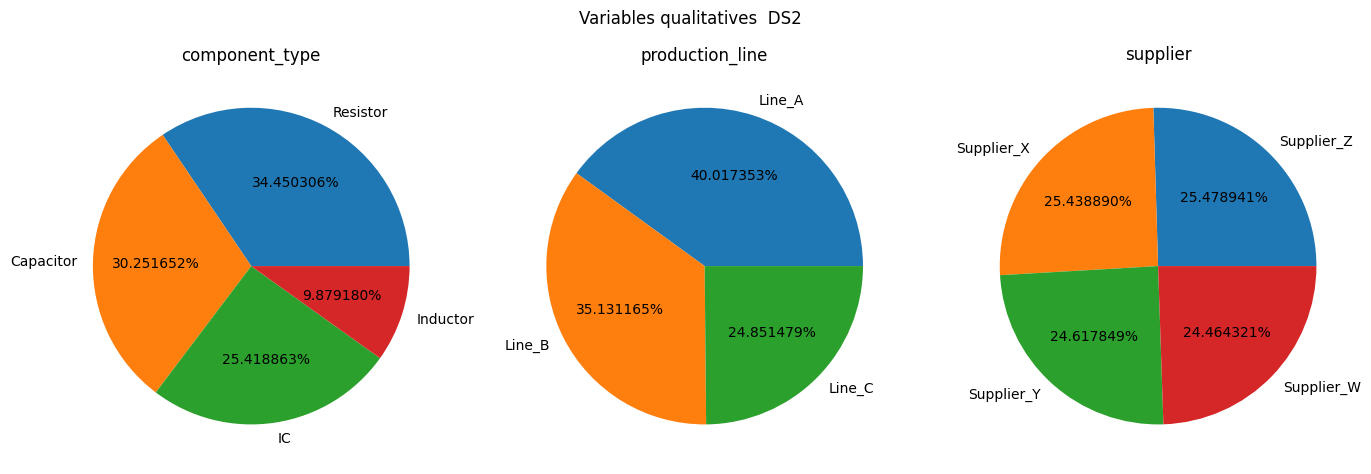

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['component_type', 'production_line', 'supplier']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1f%%')
    ax.set_title(col)
plt.suptitle("Variables qualitatives  DS2")
plt.tight_layout()
plt.show()

In [10]:
print("Taux de défauts par catégorie (DS1 vs DS2) :\n")
for col in ['component_type','production_line','supplier']:
    t1 = df1.groupby(col)['defect'].apply(lambda x: (x=='FAIL').mean()*100).round(1)
    t2 = df.groupby(col)['defect'].apply(lambda x: (x=='FAIL').mean()*100).round(1)
    comp = pd.DataFrame({'DS1_%FAIL': t1, 'DS2_%FAIL': t2, 'Diff': (t2-t1).round(1)})
    print(f"--- {col} ---")
    print(comp)
    print()

Taux de défauts par catégorie (DS1 vs DS2) :

--- component_type ---
                DS1_%FAIL  DS2_%FAIL  Diff
component_type                            
Capacitor            66.0       51.3 -14.7
IC                   38.4       30.3  -8.1
Inductor             42.2       35.3  -6.9
Resistor             41.7       31.7 -10.0

--- production_line ---
                 DS1_%FAIL  DS2_%FAIL  Diff
production_line                            
Line_A                46.2       36.4  -9.8
Line_B                48.3       37.6 -10.7
Line_C                51.0       39.8 -11.2

--- supplier ---
            DS1_%FAIL  DS2_%FAIL  Diff
supplier                              
Supplier_W       50.9       41.1  -9.8
Supplier_X       45.6       35.4 -10.2
Supplier_Y       47.1       36.3 -10.8
Supplier_Z       49.0       37.9 -11.1



Le taux de défauts baisse pour toutes les catégories Les fournisseurs et lignes de production n'ont pas d'impact différentiel marqué 

## 1. Analyse univariée par statut (OK / FAIL)

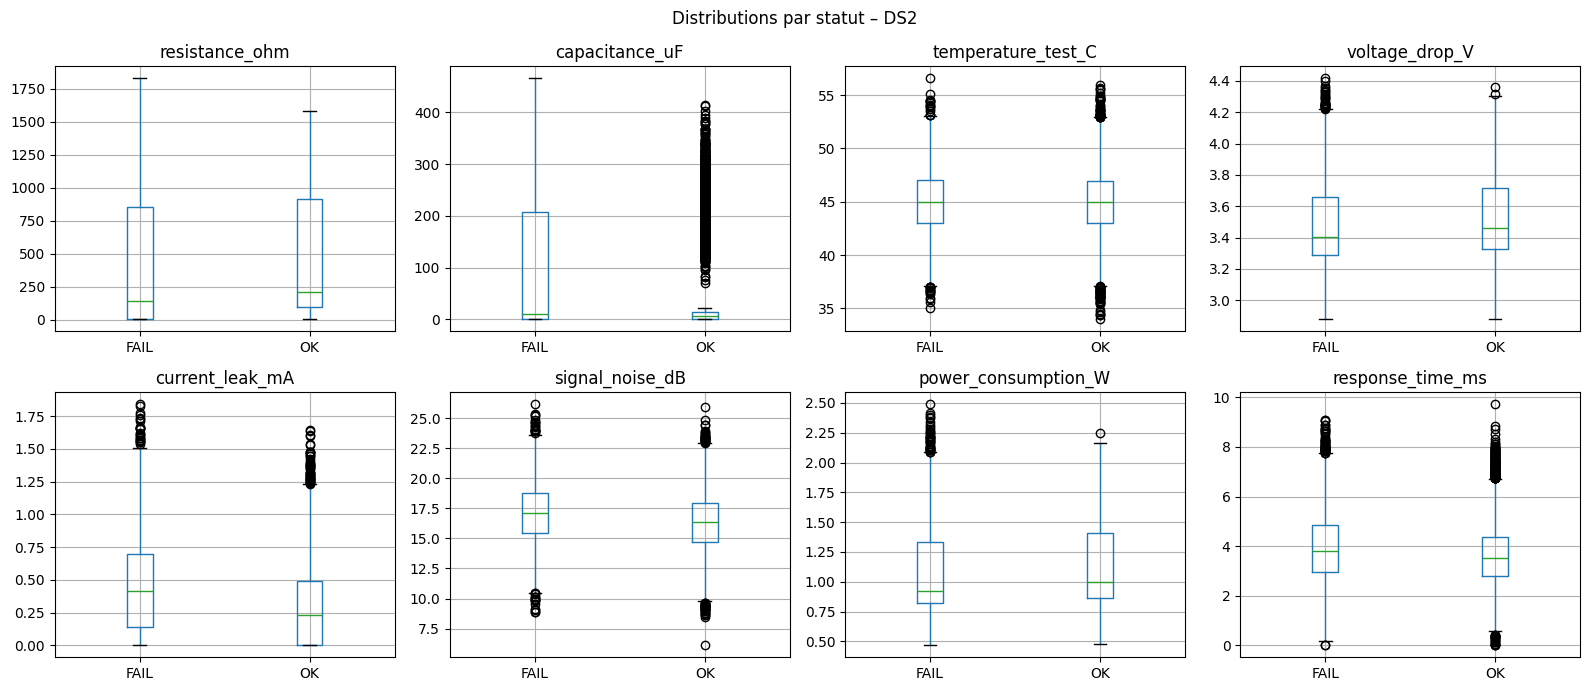

        resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
defect                                                                       
FAIL        361.511209       96.025053           45.044412        3.482722   
OK          441.683870       54.748108           44.995912        3.520446   

        current_leak_mA  signal_noise_dB  power_consumption_W  \
defect                                                          
FAIL           0.452821        17.098869             1.079807   
OK             0.296886        16.315200             1.126131   

        response_time_ms  
defect                    
FAIL            3.976784  
OK              3.632119  


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), var_quant):
    df.boxplot(column=col, by='defect', ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle("Distributions par statut – DS2")
plt.tight_layout(); plt.show()

print(df.groupby('defect')[var_quant].mean())

Les boxplots montrent que la séparation OK/FAIL est moins nette que dans le DS1, surtout pour `signal_noise_dB` où les boîtes se chevauchent presque entièrement.

## 2. Matrice de corrélations et comparaison

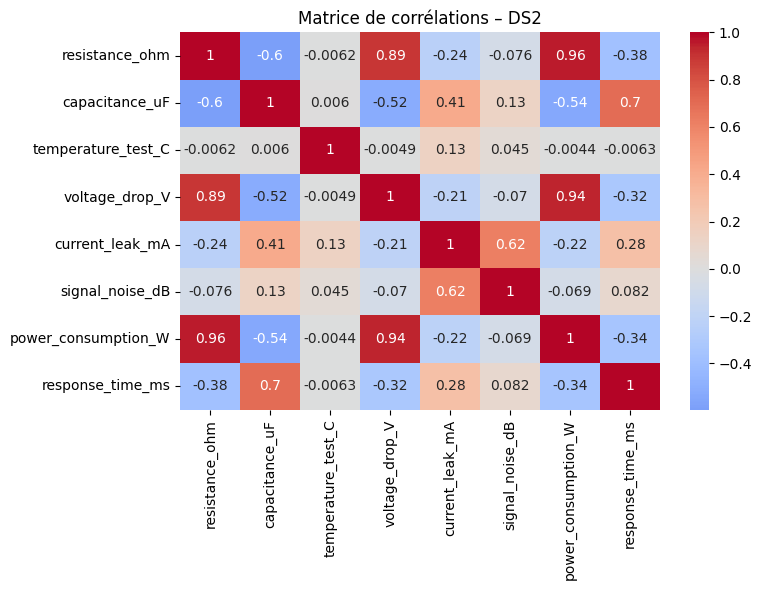


Corrélations qui changent le plus entre DS1 et DS2 :
  current_leak_mA           vs signal_noise_dB           : DS1=0.833 -> DS2=0.618
  capacitance_uF            vs current_leak_mA           : DS1=0.217 -> DS2=0.408
  current_leak_mA           vs response_time_ms          : DS1=0.151 -> DS2=0.282
  resistance_ohm            vs current_leak_mA           : DS1=-0.116 -> DS2=-0.240
  voltage_drop_V            vs current_leak_mA           : DS1=-0.099 -> DS2=-0.213


In [12]:
C = df[var_quant].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(C, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélations – DS2")
plt.tight_layout(); plt.show()

# Corrélations qui diffèrent le plus
C1 = df1[var_quant].corr()
diff = (C - C1).abs()
print("\nCorrélations qui changent le plus entre DS1 et DS2 :")
pairs = []
for i in range(len(var_quant)):
    for j in range(i+1, len(var_quant)):
        pairs.append((var_quant[i], var_quant[j], C1.iloc[i,j], C.iloc[i,j]))
pairs.sort(key=lambda x: abs(x[3]-x[2]), reverse=True)
for a, b, r1, r2 in pairs[:5]:
    print(f"  {a:25s} vs {b:25s} : DS1={r1:.3f} -> DS2={r2:.3f}")

La structure globale des corrélations est similaire (résistance/tension/puissance restent liées), mais la corrélation entre `current_leak_mA` et `signal_noise_dB` **chute de 0.83 à 0.62**. Dans le DS2, ces deux variables sont moins indépendantes l'une de l'autre

De plus, `current_leak_mA` est maintenant plus corrélé à `capacitance_uF` 

## 3. ACP centrée-réduite

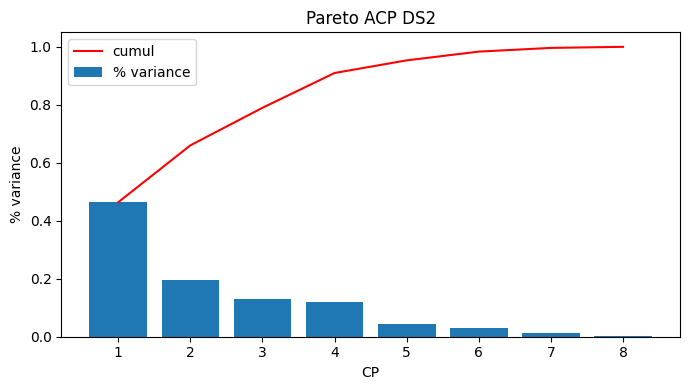

% variance : [46.3933653  19.62019035 12.9528076  12.00853229  4.35549415  3.01873602
  1.2809008   0.36997349]
Cumul      : [ 46.3933653   66.01355565  78.96636325  90.97489555  95.3303897
  98.34912571  99.63002651 100.        ]


In [14]:
X_cr = (df[var_quant] - df[var_quant].mean()) / df[var_quant].std()
acp  = PCA()
Xacp = acp.fit_transform(X_cr)
pq   = len(var_quant)

plt.figure(figsize=(7, 4))
plt.bar(range(1, pq+1), acp.explained_variance_ratio_, label='% variance')
plt.plot(range(1, pq+1), np.cumsum(acp.explained_variance_ratio_), color='red', label='cumul')
plt.xlabel("CP");
plt.ylabel("% variance")
plt.title("Pareto ACP DS2"); plt.legend()
plt.tight_layout()
plt.show()
print("% variance :", (acp.explained_variance_ratio_*100))
print("Cumul      :", (np.cumsum(acp.explained_variance_ratio_)*100))

CP1 = 46.4%, CP2 = 19.6%, pour 2 axes 66%. Très similaire au DS1 .La répartition de la variance est stable.

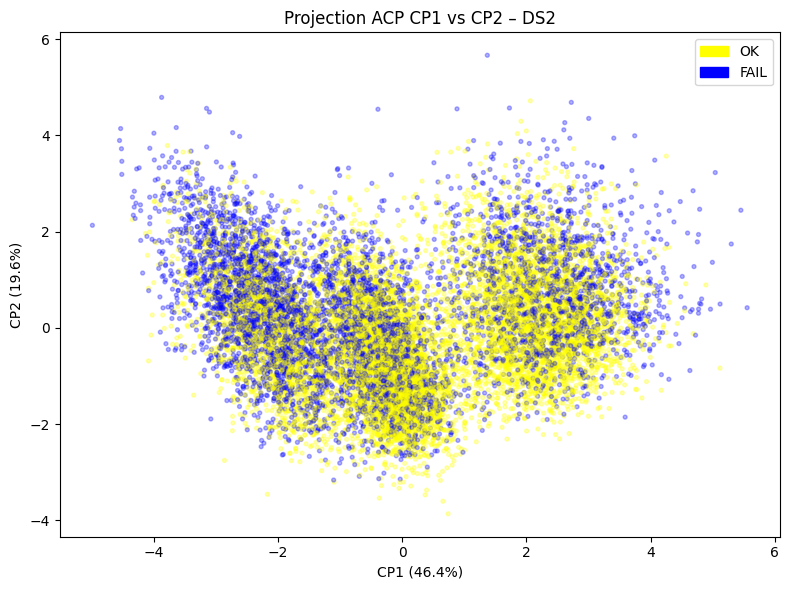

In [15]:
colors = df['defect'].map({'OK':'yellow','FAIL':'blue'})
plt.figure(figsize=(8, 6))
plt.scatter(Xacp[:,0], Xacp[:,1], c=colors, alpha=0.3, s=8)
plt.xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Projection ACP CP1 vs CP2 – DS2")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='yellow',label='OK'), Patch(color='blue',label='FAIL')])
plt.tight_layout(); plt.show()

Les classes se chevauchent sur la projection ACP

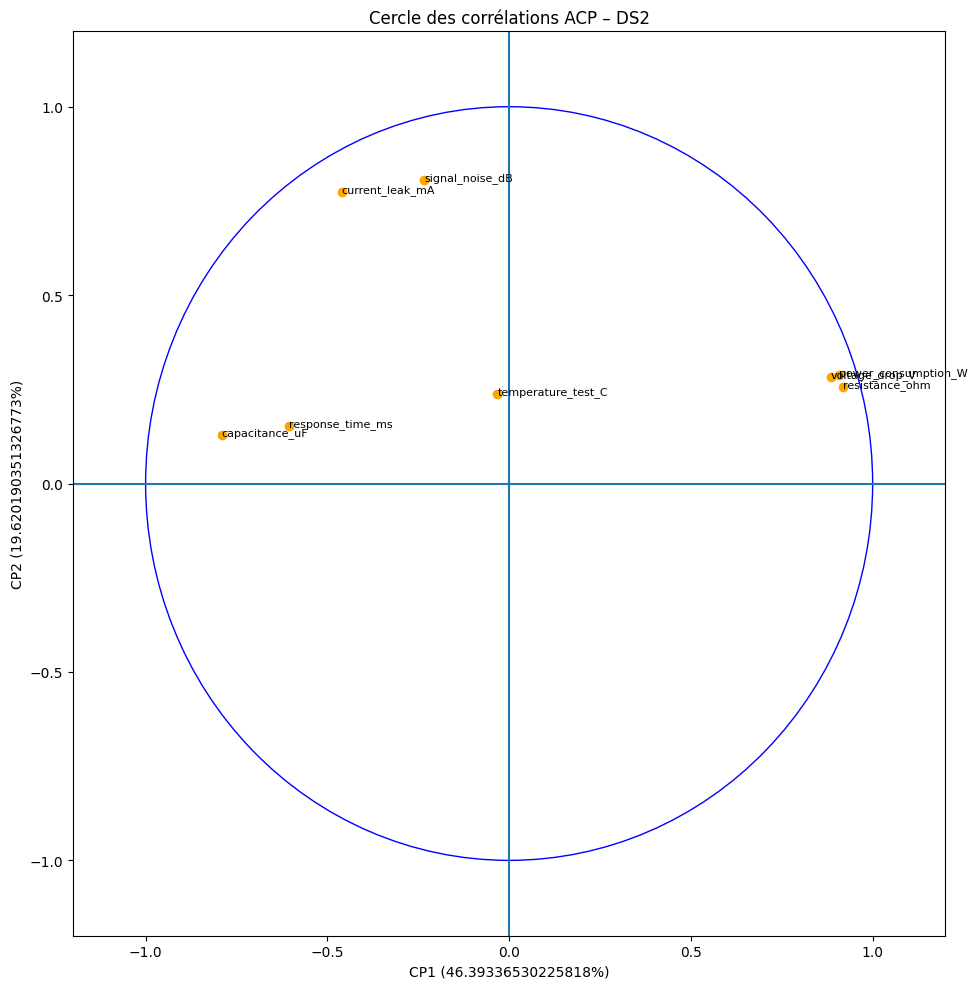

In [16]:
corr_cp = np.array([[np.corrcoef(Xacp[:,i], df[var_quant].iloc[:,j])[0,1]
                     for j in range(pq)] for i in range(pq)])

fig, ax = plt.subplots(figsize=(10,10))
ax.add_patch(plt.Circle((0,0), 1, fill=False, color='blue'))
ax.axhline(0); ax.axvline(0)
for j, v in enumerate(var_quant):
    ax.scatter(corr_cp[0,j], corr_cp[1,j], color='orange')
    ax.text(corr_cp[0,j], corr_cp[1,j], v, fontsize=8)
ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100}%)")
ax.set_ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100}%)")
ax.set_title("Cercle des corrélations ACP – DS2")
plt.tight_layout(); plt.show()

On note que `current_leak_mA` est un peu plus proche de CP1 , confirmant un couplage plus fort avec les variables électriques dans le DS2.

## 4. ADL – OK vs FAIL

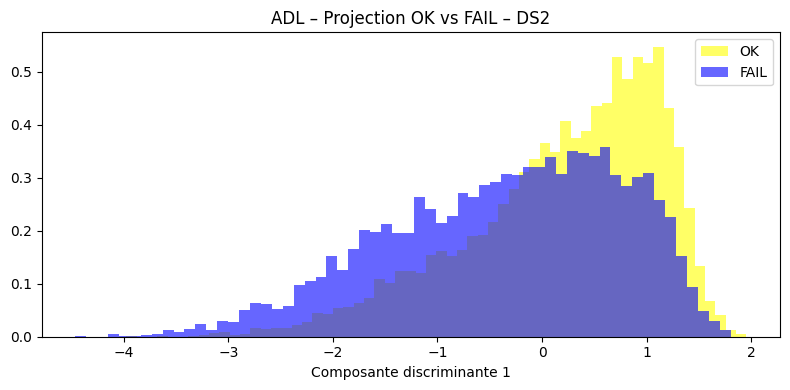

Accuracy ADL DS2 : 65.5%
Accuracy ADL DS1 : 83.3%

Corrélations avec CD1 :
  current_leak_mA           : -0.870
  capacitance_uF            : -0.735
  signal_noise_dB           : -0.590
  response_time_ms          : -0.483
  resistance_ohm            : 0.329
  voltage_drop_V            : 0.269
  power_consumption_W       : 0.250
  temperature_test_C        : -0.030


In [19]:
lda  = LinearDiscriminantAnalysis()
Xlda = lda.fit_transform(df[var_quant], df['defect'])

fig, ax = plt.subplots(figsize=(8, 4))
for status, color in [('OK','yellow'), ('FAIL','blue')]:
    idx = df['defect'] == status
    ax.hist(Xlda[idx,0], bins=60, alpha=0.6, color=color, label=status, density=True)
ax.set_xlabel("Composante discriminante 1")
ax.set_title("ADL – Projection OK vs FAIL – DS2")
ax.legend(); plt.tight_layout(); plt.show()

# Accuracy
pred = lda.predict(df[var_quant])
acc  = (pred == df['defect']).mean()
print(f"Accuracy ADL DS2 : {acc*100:.1f}%")

# Comparaison DS1
lda1 = LinearDiscriminantAnalysis()
lda1.fit(df1[var_quant], df1['defect'])
pred1 = lda1.predict(df1[var_quant])
acc1 = (pred1 == df1['defect']).mean()
print(f"Accuracy ADL DS1 : {acc1*100:.1f}%")

# Corrélations
corr_lda = {v: np.corrcoef(df[v].values, Xlda[:,0])[0,1] for v in var_quant}
print("\nCorrélations avec CD1 :")
for v, r in sorted(corr_lda.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {v:25s} : {r:.3f}")

**C'est ici la différence majeure entre DS1 et DS2 :**

L'accuracy de l'ADL chute de **83.3 %** (DS1) à **65.5 %** (DS2). L'histogramme montre que les deux distributions OK/FAIL se chevauchent beaucoup plus.

Les corrélations avec l'axe discriminant montrent que :
`current_leak_mA` reste le plus discriminant (|r| = 0.87) mais l'écart réel entre groupes est bien plus faible (0.16 vs 0.71 dans DS1)
`signal_noise_dB` passe de |r| = 0.92 (DS1) à seulement |r| = 0.59 (DS2) — il est beaucoup moins utile
`capacitance_uF` prend plus d'importance (|r| = 0.74 vs faible dans DS1)

**Conclusion :** Les capteurs du DS2 sont moins performants pour distinguer OK de FAIL. Le signal discriminant est plus faible, ce qui rend le contrôle qualité automatique moins fiable avec ces appareils.

In [21]:
from sklearn.metrics import confusion_matrix

pred = lda.predict(df[var_quant])
cm = confusion_matrix(df['defect'], pred, labels=['OK','FAIL'])
print("Matrice de confusion :")
print(pd.DataFrame(cm, index=['Réel OK','Réel FAIL'], columns=['Prédit OK','Prédit FAIL']))
acc = (pred == df['defect']).mean()
# Recall FAIL = parmi les vrais FAIL, combien sont détectés ?
recall_fail = cm[1,1] / cm[1].sum()
# Faux négatifs = FAIL classés OK (pièces défectueuses non détectées)
fn = cm[1,0]

print(f"\nAccuracy globale   : {acc*100:.1f}%")
print(f"Recall FAIL        : {recall_fail*100:.1f}%  ({cm[1,1]} détectés sur {cm[1].sum()})")
print(f"FAIL non détectés  : {fn}  (pièces défectueuses classées OK)")

Matrice de confusion :
           Prédit OK  Prédit FAIL
Réel OK         8162         1179
Réel FAIL       3984         1656

Accuracy globale   : 65.5%
Recall FAIL        : 29.4%  (1656 détectés sur 5640)
FAIL non détectés  : 3984  (pièces défectueuses classées OK)


Dans le DS1 il est de 76 %, dans le DS2 il chute à 29 % : les capteurs du DS2 laissent passer la majorité des défauts.

## 5. ADL – Par type de défaut

Effectifs DS2 : {'Solder_Issue': 4951, 'Short_Circuit': 680, 'Open_Circuit': 9}
Effectifs DS1 : {'Solder_Issue': 4036, 'Short_Circuit': 3117, 'Open_Circuit': 68}

Variance expliquée : [98.1  1.9] %


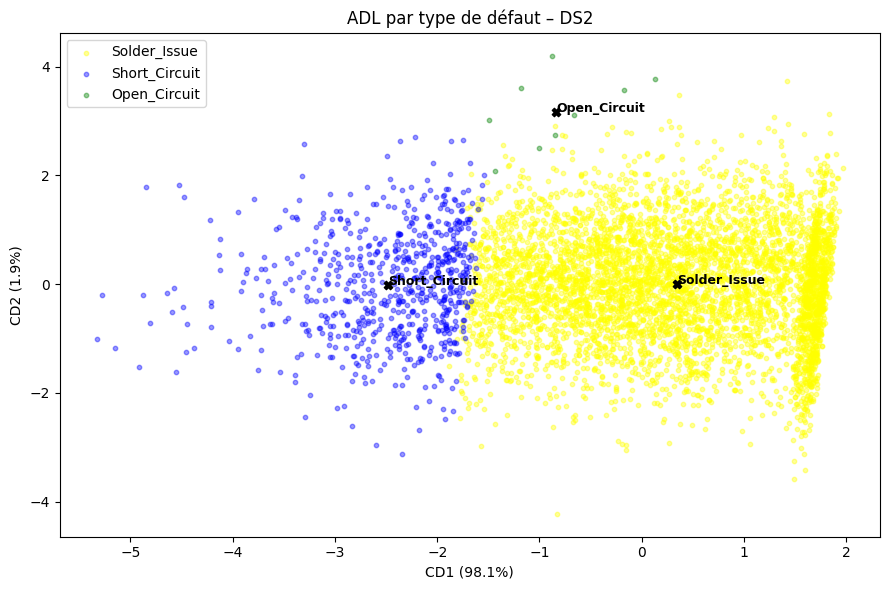

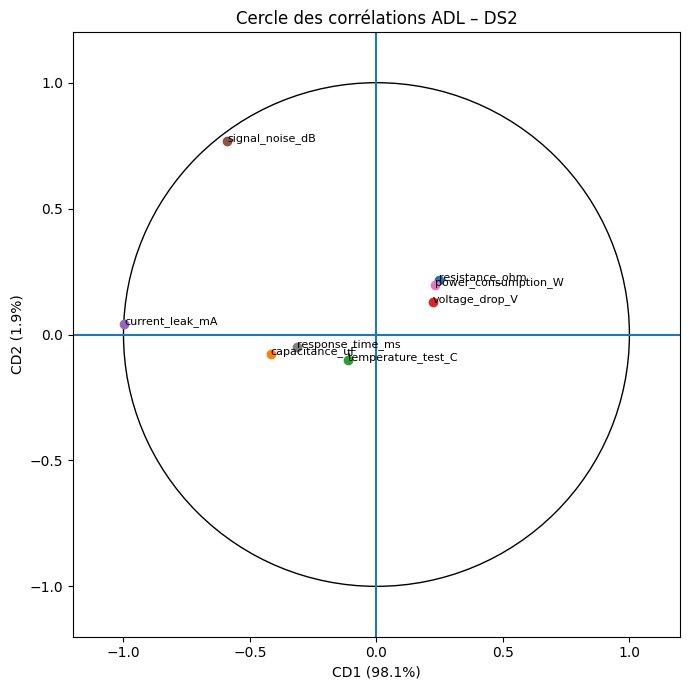

                          CD1       CD2
resistance_ohm       0.248535  0.217750
capacitance_uF      -0.418346 -0.076492
temperature_test_C  -0.112547 -0.102714
voltage_drop_V       0.222653  0.129249
current_leak_mA     -0.998141  0.040808
signal_noise_dB     -0.590172  0.767526
power_consumption_W  0.231236  0.197365
response_time_ms    -0.315684 -0.048144


In [17]:
df_fail = df[df['defect']=='FAIL'].dropna(subset=['defect_type']).copy()
print("Effectifs DS2 :", df_fail['defect_type'].value_counts().to_dict())
print("Effectifs DS1 :", df1[df1['defect']=='FAIL']['defect_type'].value_counts().to_dict())

lda2  = LinearDiscriminantAnalysis()
Xlda2 = lda2.fit_transform(df_fail[var_quant], df_fail['defect_type'])
print(f"\nVariance expliquée : {(lda2.explained_variance_ratio_*100).round(1)} %")

palette = {'Solder_Issue':'yellow','Short_Circuit':'blue','Open_Circuit':'green'}
plt.figure(figsize=(9, 6))
for dt, color in palette.items():
    idx = df_fail['defect_type'] == dt
    plt.scatter(Xlda2[idx,0], Xlda2[idx,1], c=color, alpha=0.4, s=10, label=dt)

centres     = df_fail.groupby('defect_type')[var_quant].mean()
centres_lda = lda2.transform(centres)
for i, dt in enumerate(centres.index):
    plt.scatter(centres_lda[i,0], centres_lda[i,1], c='black', marker='X', zorder=5)
    plt.text(centres_lda[i,0], centres_lda[i,1], dt, fontsize=9, fontweight='bold')
plt.xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("ADL par type de défaut – DS2")
plt.legend(); plt.tight_layout(); plt.show()

# Cercle des corrélations
corr2 = pd.DataFrame(
    {f"CD{i+1}": [np.corrcoef(df_fail[v].values, Xlda2[:,i])[0,1] for v in var_quant]
     for i in range(2)}, index=var_quant)

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Circle((0,0),1,fill=False))
ax.axhline(0); ax.axvline(0)
for v in var_quant:
    ax.scatter(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'])
    ax.text(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'], v, fontsize=8)
ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Cercle des corrélations ADL – DS2")
plt.tight_layout(); plt.show()
print(corr2)

**Différence importante dans la répartition des défauts :**
- DS1 : 4 036 Solder_Issue, **3 117 Short_Circuit** (43 % des FAIL)
- DS2 : 4 951 Solder_Issue, **680 Short_Circuit** (12 % des FAIL)

Le nombre de Short_Circuit a été divisé par 5. Cela peut indiquer soit une amélioration réelle du procédé

L'ADL conserve la même structure

In [22]:
pred2 = lda2.predict(df_fail[var_quant])
labels_defaut = sorted(df_fail['defect_type'].unique())
cm2 = confusion_matrix(df_fail['defect_type'], pred2, labels=labels_defaut)

print("Matrice de confusion (types de défaut) :")
print(pd.DataFrame(cm2, index=labels_defaut, columns=labels_defaut))
print(f"\nAccuracy : {(pred2 == df_fail['defect_type']).mean()*100:.1f}%")

Matrice de confusion (types de défaut) :
               Open_Circuit  Short_Circuit  Solder_Issue
Open_Circuit              3              0             6
Short_Circuit             0            624            56
Solder_Issue              0              7          4944

Accuracy : 98.8%


---
## Conclusion générale – Comparaison DS1 vs DS2

| Critère | DS1 | DS2 |
|---|---|---|
| Taux de défauts | 48.1 % | 37.7 % |
| Accuracy ADL (OK/FAIL) | **83.3 %** | **65.5 %** |
| Short_Circuit (% des FAIL) | 43.2 % | 12.1 % |
| Valeurs manquantes (mesures) | 0 | 20 |


**La capacité de discrimination est nettement dégradée dans le DS2.** L'accuracy ADL chute de 83 % à 66 %, principalement parce que les écarts OK/FAIL sur `current_leak_mA` et `signal_noise_dB` sont beaucoup plus faibles. Les capteurs du DS2 sont moins sensibles ou introduisent plus de bruit de mesure.

**La répartition des défauts change :** le DS2 détecte 5 fois moins de Short_Circuit. 

**Recommandation :** Les capteurs du DS1 sont préférables pour le contrôle qualité car ils offrent un meilleur pouvoir discriminant